<a href="https://colab.research.google.com/github/gandhias-a11y/colab/blob/main/semester_project_0.5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Semester Project: Project Nine from *Python Machine Learning Workbook for Beginners*

Textbook link: https://homes.luddy.indiana.edu/classes/spring2026/csci/a310-dgerman/protected/fall2022/resources/sem01.pdf

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPool2D
from tensorflow.keras.models import Model

In [3]:
import numpy as np

def load_idx3_ubyte_images(filepath):
    with open(filepath, 'rb') as f:
        # Read magic number (discarded)
        magic_number = int.from_bytes(f.read(4), 'big')
        # Read number of images
        num_images = int.from_bytes(f.read(4), 'big')
        # Read number of rows
        num_rows = int.from_bytes(f.read(4), 'big')
        # Read number of columns
        num_cols = int.from_bytes(f.read(4), 'big')
        images = np.frombuffer(f.read(), dtype=np.uint8)
        images = images.reshape(num_images, num_rows, num_cols)

    return images

def load_idx1_ubyte_labels(filepath):
    with open(filepath, 'rb') as f:
        # Read magic number (discarded)
        magic_number = int.from_bytes(f.read(4), 'big')
        # Read number of items (labels)
        num_items = int.from_bytes(f.read(4), 'big')

        # Read the label data
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        # Labels are 1-dimensional
        labels = labels.reshape(num_items)

    return labels

training_images = load_idx3_ubyte_images('emnist-letters-train-images-idx3-ubyte')
training_labels = load_idx1_ubyte_labels('emnist-letters-train-labels-idx1-ubyte')
test_images = load_idx3_ubyte_images('emnist-letters-test-images-idx3-ubyte')
test_labels = load_idx1_ubyte_labels('emnist-letters-test-labels-idx1-ubyte')

In [4]:
print(training_images.shape)
print(test_images.shape)
print(training_labels.shape)
print(test_labels.shape)

(124800, 28, 28)
(20800, 28, 28)
(124800,)
(20800,)


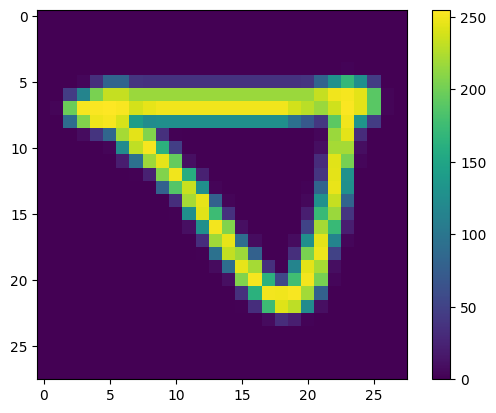

In [5]:
plt.figure()
plt.imshow(test_images[3000])
plt.colorbar()
plt.grid(False)
plt.show()

In [6]:
print(test_labels[3000])

4


In [7]:
np.unique(test_labels)

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26], dtype=uint8)

In [8]:
training_images = np.expand_dims(training_images, -1)
test_images = np.expand_dims(test_images, -1)
print(training_images.shape)

(124800, 28, 28, 1)


In [11]:
output_classes = len(set(training_labels))

input_layer = Input(shape = training_images[0].shape )

conv1 = Conv2D(32, (3,3), strides = 2, activation= 'relu')(input_layer)
maxpool1 = MaxPool2D(2, 2)(conv1)

conv2 = Conv2D(64, (3,3), strides = 2, activation= 'relu')(maxpool1)
flat1 = Flatten()(conv2)
drop1 = Dropout(0.2)(flat1)
dense1 = Dense(512, activation = 'relu')(drop1)
drop2 = Dropout(0.2)(dense1)

output_layer = Dense(output_classes+1, activation='softmax')(drop2)

In [12]:
model = Model(input_layer, output_layer)

In [13]:
model.compile(optimizer = 'adam', loss= 'sparse_categorical_crossentropy', metrics =['accuracy'])

model_history = model.fit(training_images, training_labels,batch_size = 32, epochs=20, validation_data=(test_images,test_labels), verbose=1)

Epoch 1/20
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.7152 - loss: 0.9286 - val_accuracy: 0.8328 - val_loss: 0.4922
Epoch 2/20
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.8106 - loss: 0.5736 - val_accuracy: 0.8582 - val_loss: 0.4223
Epoch 3/20
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 41s 10ms/step - accuracy: 0.8269 - loss: 0.5231 - val_accuracy: 0.8646 - val_loss: 0.4129
Epoch 4/20
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 38s 10ms/step - accuracy: 0.8355 - loss: 0.4949 - val_accuracy: 0.8654 - val_loss: 0.4017
Epoch 5/20
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.8384 - loss: 0.4822 - val_accuracy: 0.8649 - val_loss: 0.4030
Epoch 6/20
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 40s 10ms/step - accuracy: 0.8431 - loss: 0.4676 - val_accuracy: 0.8670 - val_loss: 0.4017
Epoch 7/20
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.8455 - loss: 0.4616 - val_accuracy: 0.8649 - val_loss: 0.4091
Epoch 8/20
3900/3900 ━━━━━━━━━━━━━━━━━━━━ 39s 10ms/step - accuracy: 0.8471 -

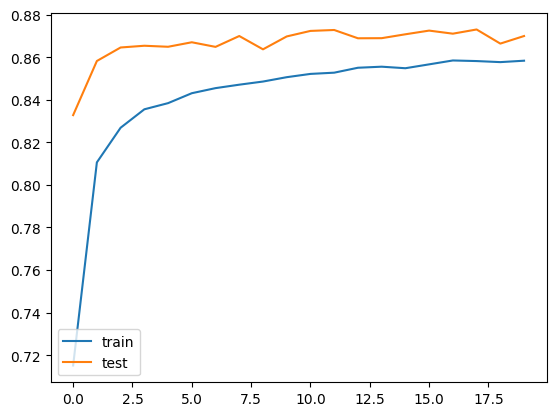

In [15]:
plt.plot(model_history.history['accuracy'], label ='accuracy')
plt.plot(model_history.history['val_accuracy'], label ='val_accuracy')
plt.legend(['train','test'], loc='lower left')

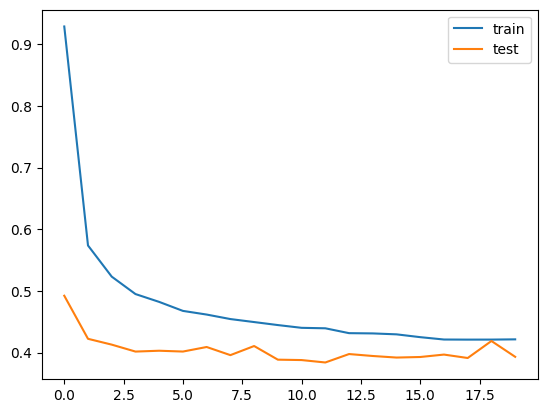

In [16]:
plt.plot(model_history.history['loss'], label = 'loss')
plt.plot(model_history.history['val_loss'], label = 'val_loss')
plt.legend(['train','test'], loc='upper right')

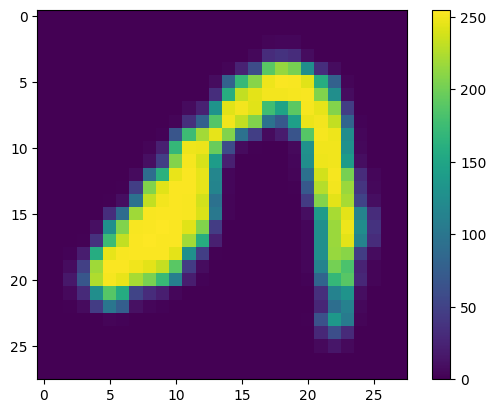

In [17]:
plt.figure()
plt.imshow(test_images[2000])
plt.colorbar()
plt.grid(False)
plt.show()

In [18]:
print(test_labels[2000])

3


In [19]:
output = model.predict(test_images)
prediction = np.argmax(output[2000])
print(prediction)

650/650 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
3
